<a href="https://colab.research.google.com/github/Prabhsimar2104/DL-Project/blob/main/ResNet50-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
base_path = "/content/drive/MyDrive/archive/chest_xray"

In [57]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

In [58]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
)

train_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    base_path + '/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [59]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [60]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

In [61]:
from tensorflow.keras.layers import GlobalAveragePooling2D

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [62]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [63]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_resnet50.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [64]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.7987 - loss: 0.4433

147/147 ━━━━━━━━━━━━━━━━━━━━ 163s 987ms/step - accuracy: 0.8409 - loss: 0.3601 - val_accuracy: 0.7390 - val_loss: 0.6763
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9069 - loss: 0.2329

147/147 ━━━━━━━━━━━━━━━━━━━━ 131s 886ms/step - accuracy: 0.9086 - loss: 0.2267 - val_accuracy: 0.7428 - val_loss: 0.5787
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 127s 862ms/step - accuracy: 0.9227 - loss: 0.1971 - val_accuracy: 0.7428 - val_loss: 0.5413
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.9333 - loss: 0.1707

147/147 ━━━━━━━━━━━━━━━━━━━━ 133s 906ms/step - accuracy: 0.9327 - loss: 0.1727 - val_accuracy: 0.9040 - val_loss: 0.1883
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.9271 - loss: 0.1821

147/147 ━━━━━━━━━━━━━━━━━━━━ 139s 885ms/step - accuracy: 0.9365 - loss: 0.1669 - val_accuracy: 0.9290 - val_loss: 0.1660
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 130s 884ms/step - accuracy: 0.9367 - loss: 0.1673 - val_accuracy: 0.9194 - val_loss: 0.1765
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 130s 883ms/step - accuracy: 0.9384 - loss: 0.1510 - val_accuracy: 0.9251 - val_loss: 0.1778
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 133s 903ms/step - accuracy: 0.9412 - loss: 0.1549 - val_accuracy: 0.9290 - val_loss: 0.1662
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 140s 889ms/step - accuracy: 0.9446 - loss: 0.1402 - val_accuracy: 0.9290 - val_loss: 0.1691
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 140s 955ms/step - accuracy: 0.9536 - loss: 0.1240 - val_accuracy: 0.9060 - val_loss: 0.1932


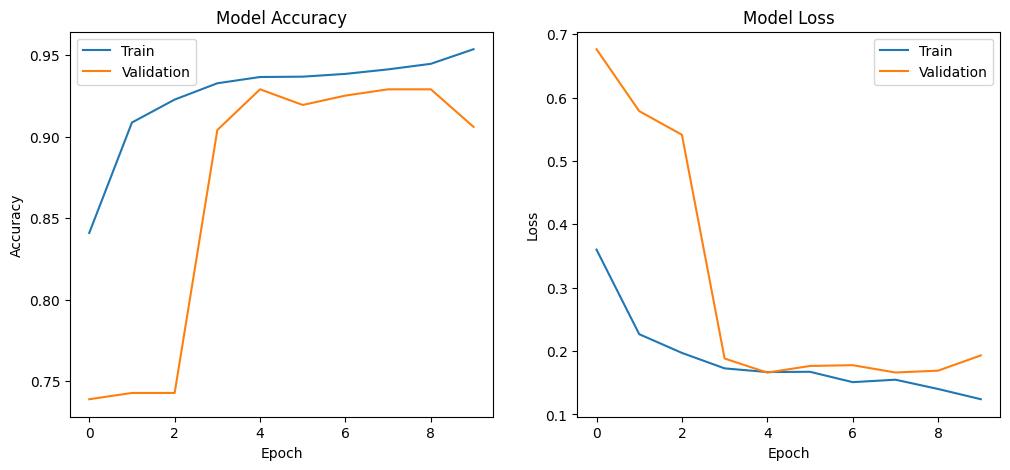

In [65]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [66]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 506ms/step - accuracy: 0.8654 - loss: 0.3092
Test Accuracy: 0.8653846383094788


In [67]:
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 578ms/step


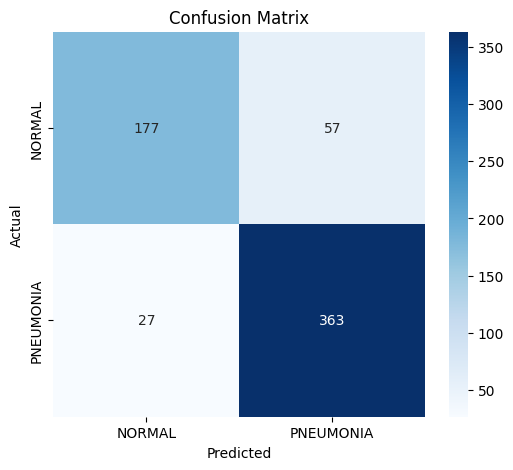

In [68]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [69]:
print(classification_report(y_true, y_pred, target_names=['NORMAL','PNEUMONIA']))

              precision    recall  f1-score   support

      NORMAL       0.87      0.76      0.81       234
   PNEUMONIA       0.86      0.93      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.87      0.86       624



In [70]:
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.8653846383094788


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 401ms/step
ROC-AUC Score: 0.9429432390970852


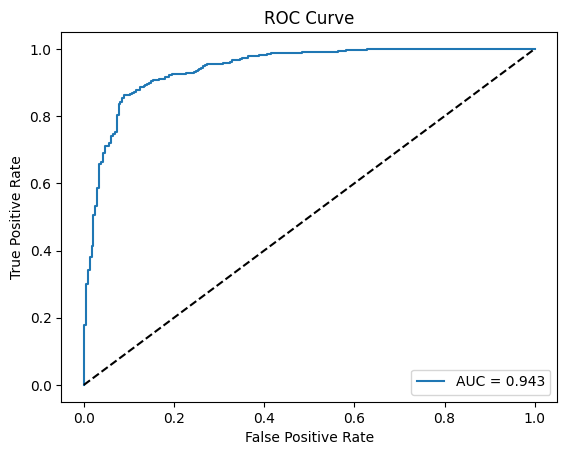

In [72]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict(test_data).ravel()
y_true = test_data.classes
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print("ROC-AUC Score:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--')  # diagonal

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

In [71]:
model.save('/content/drive/MyDrive/resnet50_model.h5')